In [2]:
# ---- Setup ----
import sys, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo

import models
from data import build_sdf_tensor, sample_circular_obstacles
from losses import compute_smoothness_cost, compute_trajectory_collision_cost
from utils import get_world_spheres_torch, query_sdf_differentiable
from training import train


# Full Model Training

In [2]:
# Overfitting 1 sample to verify that the model can learn something
training = False
if training:
    model_1_sample, history_1_sample = train(
        train_dataset       = "data/training_dataset_1_samples.pt",
        val_dataset         = None,
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder.pt",
        state_encoder_path  = "models/state_encoder.pt",
        freeze_encoders     = False,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path           = "models/warm_start_planner_overfit_1_samples.pt",
    )

In [3]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model_1_sample = torch.load("models/warm_start_planner_overfit_1_samples.pt")
    
browse_trajectories(model_1_sample, "data/training_dataset_1_samples.pt", save_name="overfit_1_sample_working")

In [4]:
# Overfitting 10 samples to verify that the model can learn something (Different arms, same environment)
training = False
if training:
    model_10_samples, history_10_samples = train(
        train_dataset       = "data/training_dataset_10_samples_different_arms.pt",
        val_dataset         = None,
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder.pt",
        state_encoder_path  = "models/state_encoder.pt",
        freeze_encoders     = False,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path           = "models/warm_start_planner_overfit_10_samples_different_arms.pt",
    )


In [5]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model = torch.load("models/warm_start_planner_overfit_10_samples_different_arms.pt")

browse_trajectories(model, "data/training_dataset_10_samples_different_arms.pt")

In [6]:
# Overfitting 10 samples to verify that the model can learn something (Different environments, same arms)
training = False
if training:
    model_10_samples, history_10_samples = train(
        train_dataset       = "data/training_dataset_10_samples_different_envs.pt",
        val_dataset         = None,
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder.pt",
        state_encoder_path  = "models/state_encoder.pt",
        freeze_encoders     = False,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path           = "models/warm_start_planner_overfit_10_samples_different_envs.pt",
    )


In [7]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model = torch.load("models/warm_start_planner_overfit_10_samples_different_envs.pt")

browse_trajectories(model, "data/training_dataset_10_samples_different_envs.pt")

In [8]:
# Overfitting on bigger dataset
training = False
if training:
    model_10_samples, history_10_samples = train(
        train_dataset       = "data/training_dataset_64_10.pt",
        val_dataset         = None,
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder.pt",
        state_encoder_path  = "models/state_encoder.pt",
        freeze_encoders     = False,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path           = "models/warm_start_planner_64_10.pt",
    )


In [9]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model = torch.load("models/warm_start_planner_64_10.pt")

browse_trajectories(model, "data/training_dataset_64_10.pt", save_name="overfit_64_10_working")

In [10]:
# Overfitting on bigger dataset with two obstacles
training = False
if training:
    model_10_samples, history_10_samples = train(
        train_dataset       = "data/training_dataset_64_10_2obs.pt",
        val_dataset         = None,
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder.pt",
        state_encoder_path  = "models/state_encoder.pt",
        freeze_encoders     = False,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path           = "models/warm_start_planner_64_10_2obs.pt",
    )


In [11]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model = torch.load("models/warm_start_planner_64_10_2obs.pt")

browse_trajectories(model, "data/training_dataset_64_10_2obs.pt", save_name="overfit_64_10_2obs_working")

In [12]:
# Now train Bigboy
training = False
if training:
    model, history = train(
        train_dataset       = "data/good_dataset_train.pt",
        val_dataset         = "data/good_dataset_val.pt",
        # Model
        T                   = 50,
        C                   = 10,
        # Pre-trained encoders (set to None to train from scratch)
        env_encoder_path    = "models/env_encoder_finetuned.pt",
        state_encoder_path  = "models/state_encoder_finetuned.pt",
        freeze_encoders     = True,
        # Training
        n_epochs            = 3000,
        batch_size          = 10,
        lr                  = 1e-3,
        # Loss weights
        w_coll              = 50.0,
        w_joints            = 0.1,
        w_smooth            = 1.0,
        w_spacing           = 2,
        w_explore           = 2,
        # Loss parameters
        explore_threshold   = 0.5,
        collision_eps       = 0.8,
        dt                  = 0.1,
        # Misc
        log_every           = 100,
        device              = None,
        save_path                = "models/warm_start_planner.pt",
        save_env_encoder_path    = "models/env_encoder_finetuned.pt",
        save_state_encoder_path  = "models/state_encoder_finetuned.pt",
    )


In [13]:
# ---- Visualize predicted trajectories ----
from visualization import browse_trajectories
model = torch.load("models/warm_start_planner.pt")

browse_trajectories(model, "data/good_dataset_val.pt", save_name="val_trajectories_working")

# Autoencoder State Training

Training State Autoencoder:   0%|          | 0/5000 [00:00<?, ?it/s]

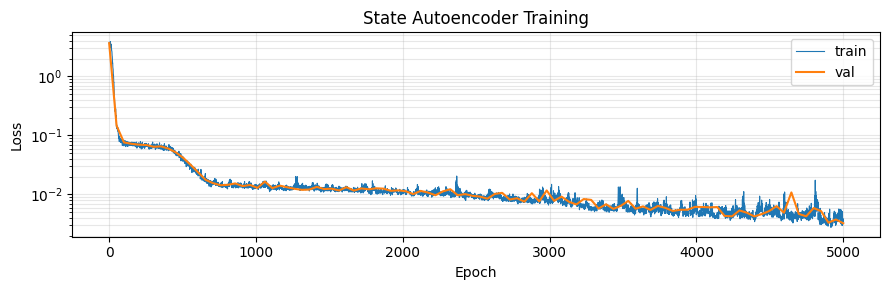

Test loss: 0.003459
Saved: models/state_autoencoder.pt  (encoder → models/state_encoder.pt)


In [2]:
# ---- Train State Autoencoder ----
from training import train_state_autoencoder

LINKLENGTHS = [0.3, 0.4, 0.3]

state_ae, state_ae_history = train_state_autoencoder(
    linklengths=LINKLENGTHS,
    save_path="models/state_autoencoder.pt",
)

# Autoencoder environment training

In [2]:
# ---- Train Environment Autoencoder ----
from training import train_env_autoencoder

env_ae, env_ae_history = train_env_autoencoder(
    dataset_path="data/sdf_dataset.pt",
    save_path="models/env_autoencoder.pt",
)

Training Env Autoencoder:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 